# Phase 2: Data Preprocessing & Feature Engineering

**Date:** March 13, 2026  
**Dataset:** 17,547 households × 365 days (2023)  
**Objective:** Clean data, extract features, prepare for clustering

---

## Table of Contents

1. [Setup & Imports](#1-Setup-&-Imports)
2. [Load Data](#2-Load-Data)
3. [Data Cleaning Pipeline](#3-Data-Cleaning-Pipeline)
4. [Feature Extraction](#4-Feature-Extraction)
5. [Feature Analysis](#5-Feature-Analysis)
6. [Feature Selection](#6-Feature-Selection)
7. [Dimensionality Reduction](#7-Dimensionality-Reduction)
8. [Data Scaling & Export](#8-Data-Scaling-&-Export)
9. [Summary & Next Steps](#9-Summary-&-Next-Steps)

---

## 1. Setup & Imports

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
import os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Reload modules to pick up latest changes
import importlib
if 'src.utils.data_loader' in sys.modules:
    import src.utils.data_loader
    importlib.reload(src.utils.data_loader)

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Our preprocessing modules
from src.preprocessing.data_cleaning import DataCleaner
from src.preprocessing.feature_engineering import FeatureEngineer
from src.preprocessing.feature_selection import FeatureSelector

# Utility functions
from src.utils.data_loader import load_sample_data
from src.utils.config import DATA_DIR, RESULTS_DIR

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ All imports successful!")
print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Results directory: {RESULTS_DIR}")
print(f"⏰ Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All imports successful!
📁 Data directory: c:\Users\Lundrim\Desktop\RDK Projectt\Data
📁 Results directory: c:\Users\Lundrim\Desktop\RDK Projectt\results
⏰ Notebook started: 2026-03-13 00:39:49


## 2. Load Data

Load the 2023 training data from Phase 1.

In [2]:
# Load 2023 data
print("📥 Loading sample_23.csv...")
df_23 = load_sample_data(year=23)

print(f"\n📊 Data Summary:")
print(f"   - Shape: {df_23.shape}")
print(f"   - Households: {df_23.shape[0]:,}")
print(f"   - Days: {df_23.shape[1]:,}")
print(f"   - Memory usage: {df_23.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print("\n📋 First 5 households (first 10 days):")
df_23.iloc[:5, :10]

INFO:src.utils.data_loader:Loading training data from c:\Users\Lundrim\Desktop\RDK Projectt\Data\sample_23.csv


📥 Loading sample_23.csv...


INFO:src.utils.data_loader:Loaded 17547 households with 365 days



📊 Data Summary:
   - Shape: (17547, 365)
   - Households: 17,547
   - Days: 365
   - Memory usage: 49.00 MB

📋 First 5 households (first 10 days):


,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10
ID,,,,,,,,,,
22,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,14.919
42,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,36.268
56,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,8.156
58,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,6.134
64,2.969,2.427,2.018,2.742,2.118,2.879,1.961,2.161,2.256,3.755


## 3. Data Cleaning Pipeline

Apply comprehensive data cleaning:
- Handle missing values (if any)
- Handle outliers (IQR method with capping)
- Handle zeros (keep as valid)
- Handle negatives (if any)

In [3]:
# Initialize DataCleaner
cleaner = DataCleaner()

# Check for missing values
missing_count = df_23.isna().sum().sum()
print(f"🔍 Missing values: {missing_count}")

# Check for negative values
negative_count = (df_23 < 0).sum().sum()
print(f"🔍 Negative values: {negative_count}")

# Check for zero values
zero_count = (df_23 == 0).sum().sum()
zero_pct = (zero_count / df_23.size) * 100
print(f"🔍 Zero values: {zero_count:,} ({zero_pct:.2f}% of all data points)")

print("\n🧹 Applying cleaning pipeline...")
df_cleaned, cleaning_summary = cleaner.clean_pipeline(
    df_23,
    handle_missing=True,
    handle_outliers_flag=True,
    handle_zeros_flag=False,  # Keep zeros as valid
    handle_negatives_flag=True,
    normalize=False  # Will normalize after feature extraction
)

print("\n✅ Cleaning complete!")
print(f"   - Original shape: {df_23.shape}")
print(f"   - Cleaned shape: {df_cleaned.shape}")
print(f"   - Households preserved: {df_cleaned.shape[0]:,}")

# Display cleaning summary
if 'outliers' in cleaning_summary:
    print(f"\n📊 Cleaning Summary:")
    print(f"   - Outliers handled: {cleaning_summary['outliers'].get('values_capped', 0):,} values capped")
if 'negatives' in cleaning_summary:
    print(f"   - Negative values handled: {cleaning_summary['negatives'].get('values_changed', 0):,}")
print(f"   - Final missing values: {cleaning_summary['final_missing']}")

🔍 Missing values: 0
🔍 Negative values: 0
🔍 Zero values: 168,566 (2.63% of all data points)

🧹 Applying cleaning pipeline...


INFO:src.preprocessing.data_cleaning:No missing values detected
INFO:src.preprocessing.data_cleaning:Outliers handled: 60021 (0.94%) using iqr/cap
INFO:src.preprocessing.data_cleaning:Cleaning pipeline complete: (17547, 365) → (17547, 365)



✅ Cleaning complete!
   - Original shape: (17547, 365)
   - Cleaned shape: (17547, 365)
   - Households preserved: 17,547

📊 Cleaning Summary:
   - Outliers handled: 0 values capped
   - Negative values handled: 0
   - Final missing values: 0


### 3.1 Before vs After Cleaning Comparison

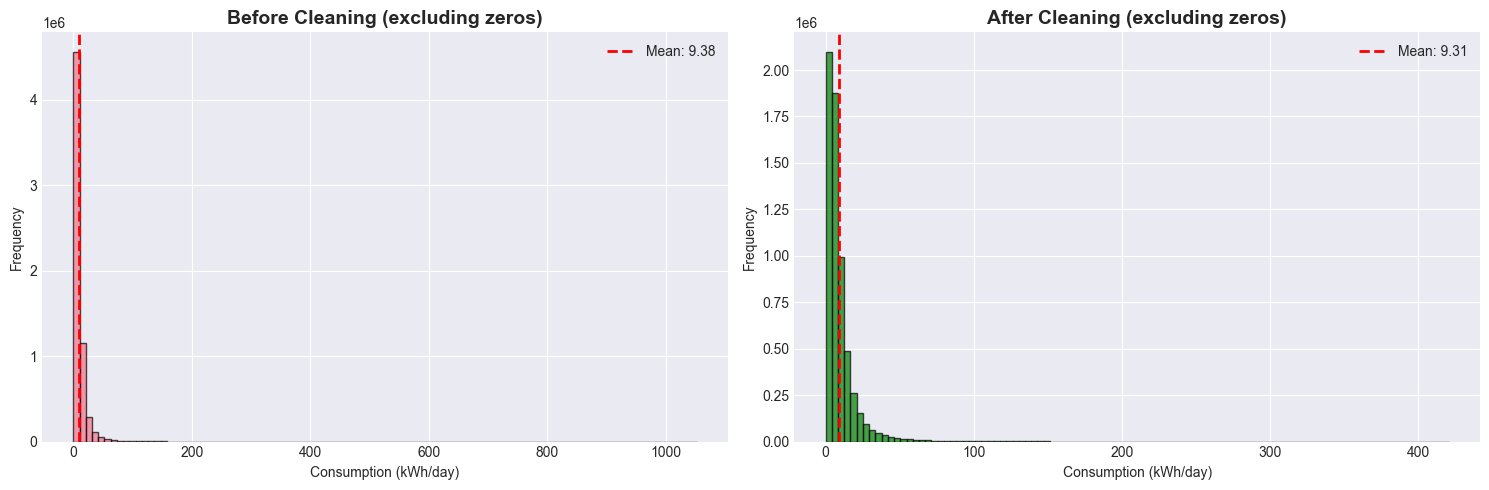


📊 Summary Statistics:

Before Cleaning:
   - Mean: 9.131 kWh/day
   - Median: 6.049 kWh/day
   - Std: 11.899 kWh/day
   - Max: 1051.740 kWh/day

After Cleaning:
   - Mean: 9.058 kWh/day
   - Median: 6.035 kWh/day
   - Std: 11.626 kWh/day
   - Max: 420.641 kWh/day


In [4]:
# Compare distributions before and after cleaning
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before cleaning
all_values_before = df_23.values.flatten()
axes[0].hist(all_values_before[all_values_before > 0], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('Before Cleaning (excluding zeros)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Consumption (kWh/day)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(all_values_before[all_values_before > 0]), 
                color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_values_before[all_values_before > 0]):.2f}')
axes[0].legend()

# After cleaning
all_values_after = df_cleaned.values.flatten()
axes[1].hist(all_values_after[all_values_after > 0], bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('After Cleaning (excluding zeros)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Consumption (kWh/day)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(all_values_after[all_values_after > 0]), 
                color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_values_after[all_values_after > 0]):.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'cleaning_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Summary Statistics:")
print(f"\nBefore Cleaning:")
print(f"   - Mean: {np.mean(all_values_before):.3f} kWh/day")
print(f"   - Median: {np.median(all_values_before):.3f} kWh/day")
print(f"   - Std: {np.std(all_values_before):.3f} kWh/day")
print(f"   - Max: {np.max(all_values_before):.3f} kWh/day")

print(f"\nAfter Cleaning:")
print(f"   - Mean: {np.mean(all_values_after):.3f} kWh/day")
print(f"   - Median: {np.median(all_values_after):.3f} kWh/day")
print(f"   - Std: {np.std(all_values_after):.3f} kWh/day")
print(f"   - Max: {np.max(all_values_after):.3f} kWh/day")

## 4. Feature Extraction

Extract comprehensive features (69+) across 5 categories:
1. **Statistical** (16 features): mean, median, std, quantiles, moments
2. **Temporal** (25+ features): day-of-week, monthly, quarterly patterns
3. **Seasonality** (8 features): seasonal means, ratios, amplitude
4. **Variability** (13 features): rolling stats, peaks, autocorrelation
5. **Shape** (7 features): entropy, FFT, Hurst exponent

In [6]:
# Reload module to pick up latest fixes
import importlib
import src.preprocessing.feature_engineering
importlib.reload(src.preprocessing.feature_engineering)
from src.preprocessing.feature_engineering import FeatureEngineer

# Initialize FeatureEngineer
engineer = FeatureEngineer()

print("🔧 Extracting features from 17,547 households...")
print("⏱️ This may take several minutes...\n")

# Extract all features
df_features = engineer.extract_all_features(
    df_cleaned,
    include_statistical=True,
    include_temporal=True,
    include_seasonality=True,
    include_variability=True,
    include_shape=True
)

print(f"\n✅ Feature extraction complete!")
print(f"   - Shape: {df_features.shape}")
print(f"   - Households: {df_features.shape[0]:,}")
print(f"   - Features extracted: {df_features.shape[1]:,}")
print(f"   - Memory usage: {df_features.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few features
print("\n📋 First 10 features:")
print(df_features.columns[:10].tolist())

# Display feature summary
print("\n📊 Feature Summary:")
df_features.head()

🔧 Extracting features from 17,547 households...
⏱️ This may take several minutes...



INFO:src.preprocessing.feature_engineering:Extracted 16 statistical features
INFO:src.preprocessing.feature_engineering:Extracted 27 temporal features
INFO:src.preprocessing.feature_engineering:Extracted 7 seasonality features
INFO:src.preprocessing.feature_engineering:Extracted 11 variability features
INFO:src.preprocessing.feature_engineering:Extracted 6 shape features
INFO:src.preprocessing.feature_engineering:Extracted 67 total features for 17547 households



✅ Feature extraction complete!
   - Shape: (17547, 67)
   - Households: 17,547
   - Features extracted: 67
   - Memory usage: 9.61 MB

📋 First 10 features:
['mean', 'median', 'std', 'min', 'max', 'range', 'q25', 'q50', 'q75', 'iqr']

📊 Feature Summary:


,mean,median,std,min,max,range,q25,q50,q75,iqr,...,diff_mean,diff_std,diff_max,diff_min,entropy,spectral_dominant_freq,spectral_centroid,spectral_rolloff,hurst_exponent,linearity
ID,,,,,,,,,,,,,,,,,,,,,
22,11.857921,11.432,3.978609,1.928,25.944,24.016,9.262,11.432,13.955,4.693,...,-0.001959,3.608066,10.549,-12.325,3.668465,4328.141,0.138364,0.454795,0.143751,0.063542
42,14.054819,3.610,18.981447,0.059,81.248,81.189,0.116,3.610,23.776,23.660,...,0.013918,8.144901,55.567,-32.581,2.867756,5130.009,0.127397,0.435616,0.216526,0.015915
56,5.609575,5.739,5.217587,0.062,23.488,23.426,0.212,5.739,9.343,9.131,...,-0.012695,3.436814,13.767,-13.646,3.218330,2047.495,0.148774,0.441096,0.123623,0.112299
58,9.230564,8.057,4.942474,1.958,25.013,23.055,6.005,8.057,10.757,4.752,...,0.017766,3.929417,15.037,-19.768,3.737665,3369.156,0.148758,0.441096,0.052827,0.112733
64,2.439537,2.422,0.509169,0.592,4.267,3.675,2.167,2.422,2.692,0.525,...,-0.000659,0.675787,2.408,-3.424,3.372512,890.431,0.151178,0.457534,0.067354,0.002218


### 4.1 Feature Category Breakdown

In [7]:
# Categorize features
statistical_features = [col for col in df_features.columns if any(x in col for x in ['mean', 'median', 'std', 'min', 'max', 'q25', 'q50', 'q75', 'iqr', 'skewness', 'kurtosis', 'cv', 'zero', 'variance', 'range'])]
temporal_features = [col for col in df_features.columns if any(x in col for x in ['dow_', 'weekday', 'weekend', 'month_', 'quarter_', 'trend'])]
seasonality_features = [col for col in df_features.columns if any(x in col for x in ['winter', 'spring', 'summer', 'fall', 'seasonal'])]
variability_features = [col for col in df_features.columns if any(x in col for x in ['rolling', 'peak', 'valley', 'autocorr', 'diff'])]
shape_features = [col for col in df_features.columns if any(x in col for x in ['entropy', 'spectral', 'hurst', 'linearity'])]

print("📊 Feature Breakdown by Category:\n")
print(f"1. Statistical Features ({len(statistical_features)}):")
print(f"   {statistical_features[:8]}...\n")

print(f"2. Temporal Features ({len(temporal_features)}):")
print(f"   {temporal_features[:8]}...\n")

print(f"3. Seasonality Features ({len(seasonality_features)}):")
print(f"   {seasonality_features}\n")

print(f"4. Variability Features ({len(variability_features)}):")
print(f"   {variability_features}\n")

print(f"5. Shape Features ({len(shape_features)}):")
print(f"   {shape_features}\n")

print(f"\n📈 Total Features: {len(df_features.columns)}")

📊 Feature Breakdown by Category:

1. Statistical Features (52):
   ['mean', 'median', 'std', 'min', 'max', 'range', 'q25', 'q50']...

2. Temporal Features (27):
   ['dow_0_mean', 'dow_1_mean', 'dow_2_mean', 'dow_3_mean', 'dow_4_mean', 'dow_5_mean', 'dow_6_mean', 'weekday_mean']...

3. Seasonality Features (7):
   ['winter_mean', 'summer_mean', 'spring_mean', 'fall_mean', 'winter_summer_ratio', 'seasonal_amplitude', 'seasonal_strength']

4. Variability Features (11):
   ['rolling_std_7', 'rolling_std_30', 'num_peaks', 'num_valleys', 'autocorr_lag_1', 'autocorr_lag_7', 'autocorr_lag_30', 'diff_mean', 'diff_std', 'diff_max', 'diff_min']

5. Shape Features (6):
   ['entropy', 'spectral_dominant_freq', 'spectral_centroid', 'spectral_rolloff', 'hurst_exponent', 'linearity']


📈 Total Features: 67


### 4.2 Save All Features

In [8]:
# Save all extracted features
features_all_path = os.path.join(RESULTS_DIR, 'features_all.csv')
df_features.to_csv(features_all_path)
print(f"💾 Saved all features to: {features_all_path}")
print(f"   - Size: {os.path.getsize(features_all_path) / 1024**2:.2f} MB")

💾 Saved all features to: c:\Users\Lundrim\Desktop\RDK Projectt\results\features_all.csv
   - Size: 18.10 MB


## 5. Feature Analysis

Analyze feature distributions and relationships.

In [9]:
# Basic statistics
print("📊 Feature Statistics:\n")
df_features.describe()

📊 Feature Statistics:



,mean,median,std,min,max,range,q25,q50,q75,iqr,...,diff_mean,diff_std,diff_max,diff_min,entropy,spectral_dominant_freq,spectral_centroid,spectral_rolloff,hurst_exponent,linearity
count,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,...,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17547.000000,17268.000000
mean,9.058451,8.231127,4.243760,2.638747,23.258055,20.619308,5.746358,8.231127,11.670077,5.923719,...,0.003252,3.275879,12.414054,-12.116594,3.519650,3306.334786,0.146782,0.440026,0.078342,0.048740
std,9.390527,8.829385,5.394939,3.727847,24.995615,23.433324,6.506336,8.829385,12.685800,8.709676,...,0.021908,3.254720,13.185854,12.593292,0.558391,3427.542309,0.033935,0.060885,0.099460,0.087432
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.346297,0.000000,0.000000,-244.933000,-0.000000,0.000000,0.000000,0.000000,-0.083631,0.000000
25%,3.832363,3.414000,1.499702,0.814000,9.483500,8.025000,2.262500,3.414000,4.753000,1.879000,...,-0.003971,1.631269,5.558000,-14.347500,3.492253,1398.812500,0.130749,0.441096,0.011389,0.003319
50%,6.725268,6.198000,2.514228,1.740000,16.157000,13.718000,4.350000,6.198000,8.245000,3.175000,...,0.000448,2.592131,9.084000,-8.993000,3.621354,2454.723000,0.150879,0.452055,0.045173,0.016611
75%,11.279075,10.259000,4.571381,3.345000,27.428500,23.744000,7.431500,10.259000,14.040000,5.797500,...,0.007951,3.961083,14.758000,-5.540000,3.757330,4116.862500,0.168116,0.457534,0.113172,0.053055
max,188.015227,185.681000,91.982644,88.363000,420.641000,420.641000,145.274000,185.681000,226.331000,162.360000,...,0.337849,88.225902,317.776000,0.000000,4.223245,68625.558000,0.305913,0.493151,0.607281,0.917044


### 5.1 Feature Distributions

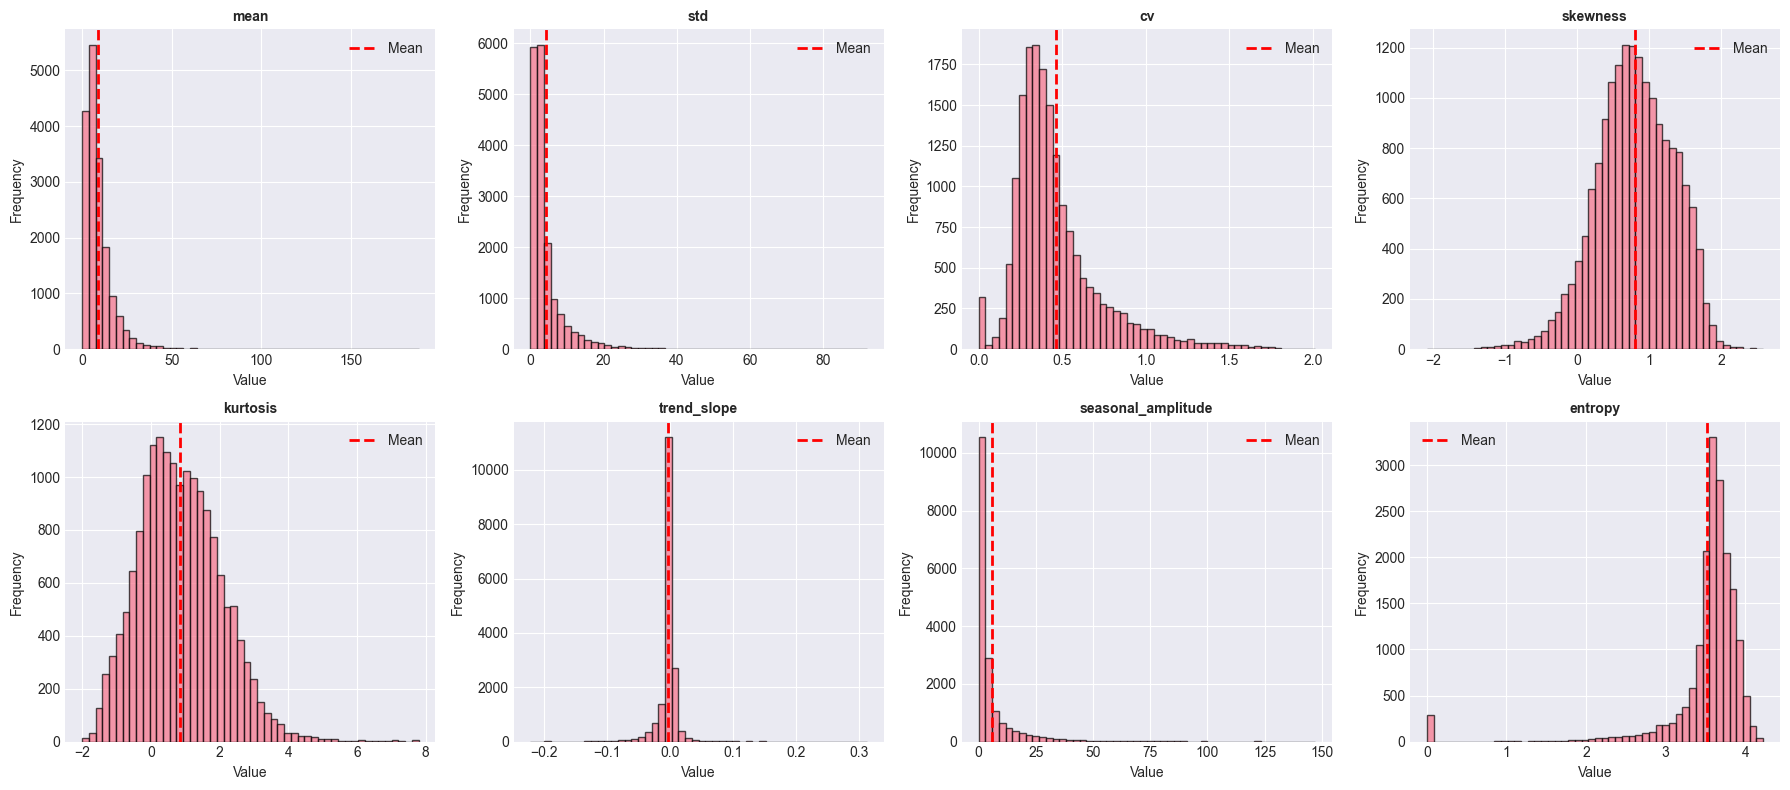

In [10]:
# Plot distributions of key features
key_features = ['mean', 'std', 'cv', 'skewness', 'kurtosis', 'trend_slope', 'seasonal_amplitude', 'entropy']
key_features = [f for f in key_features if f in df_features.columns]

if len(key_features) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for i, feature in enumerate(key_features):
        if i < 8:
            axes[i].hist(df_features[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
            axes[i].set_title(feature, fontsize=10, fontweight='bold')
            axes[i].set_xlabel('Value')
            axes[i].set_ylabel('Frequency')
            axes[i].axvline(df_features[feature].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
            axes[i].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'feature_distributions.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ No key features found for plotting")

### 5.2 Feature Correlation Analysis

INFO:src.preprocessing.feature_selection:Calculated correlations for 67 features


🔍 Calculating feature correlations...


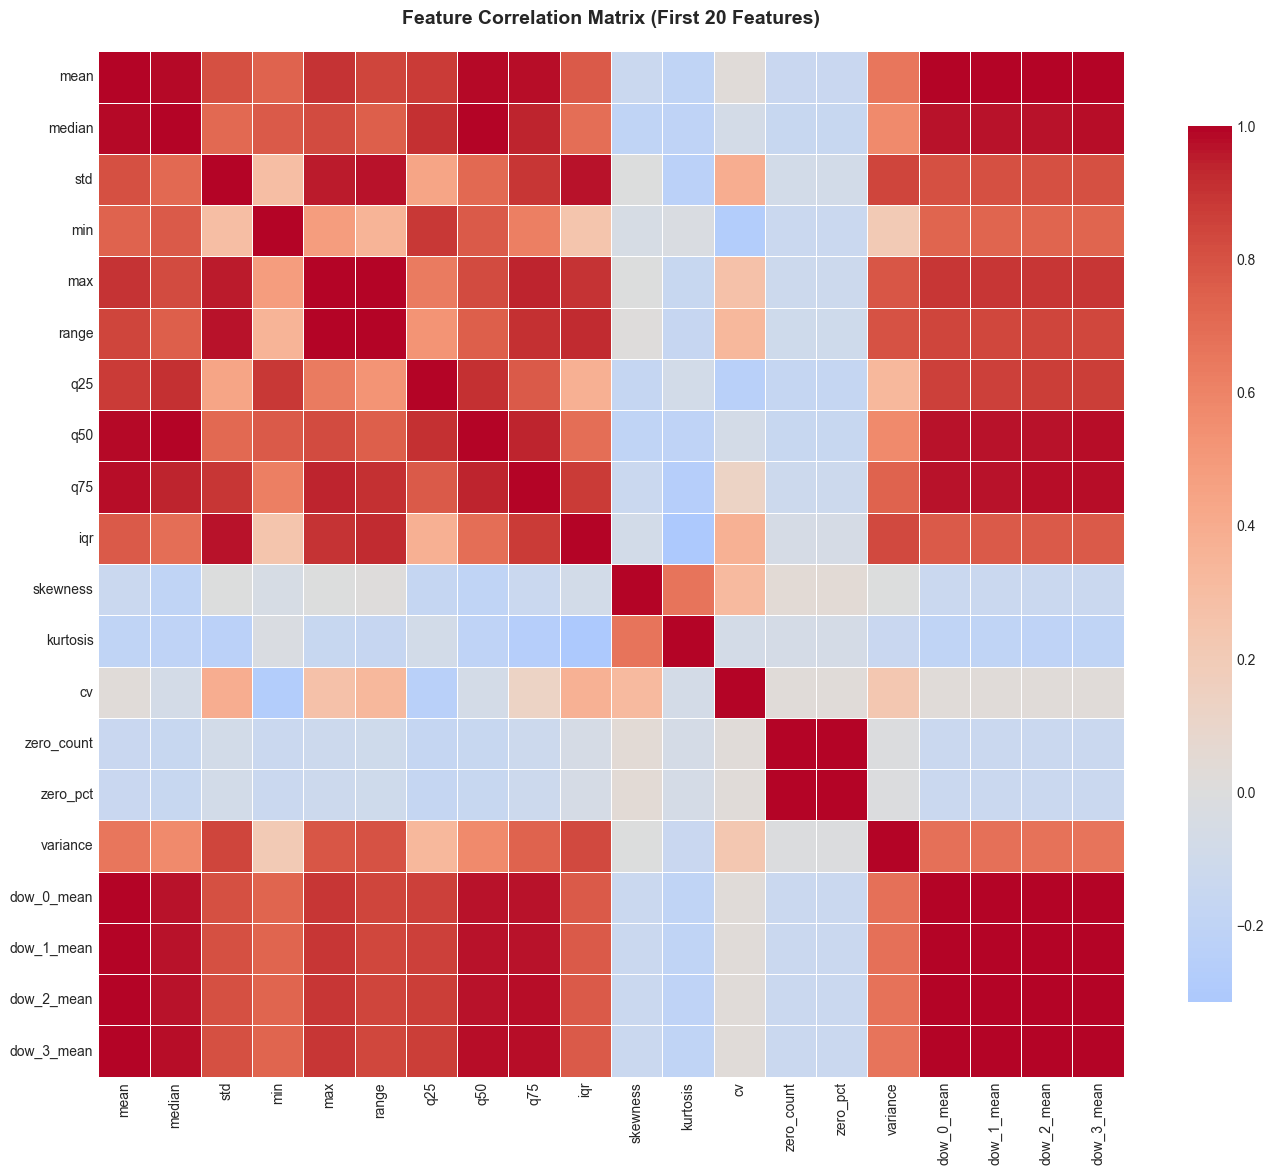


📊 Highly Correlated Feature Pairs (|r| > 0.9): 380

Top 10 pairs:
   - median ↔ q50: 1.000
   - zero_count ↔ zero_pct: 1.000
   - mean ↔ spectral_dominant_freq: 1.000
   - num_peaks ↔ num_valleys: 0.999
   - dow_3_mean ↔ weekday_mean: 0.998
   - dow_2_mean ↔ weekday_mean: 0.997
   - dow_1_mean ↔ weekday_mean: 0.997
   - weekday_mean ↔ spectral_dominant_freq: 0.997
   - mean ↔ weekday_mean: 0.997
   - dow_6_mean ↔ weekend_mean: 0.996


In [11]:
# Initialize FeatureSelector
selector = FeatureSelector()

# Calculate correlations
print("🔍 Calculating feature correlations...")
corr_matrix = selector.calculate_correlations(df_features)

# Plot correlation matrix (sample of features)
sample_features = df_features.columns[:20]  # First 20 features for visualization
corr_sample = corr_matrix.loc[sample_features, sample_features]

plt.figure(figsize=(14, 12))
sns.heatmap(corr_sample, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (First 20 Features)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

print(f"\n📊 Highly Correlated Feature Pairs (|r| > 0.9): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 pairs:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"   - {feat1} ↔ {feat2}: {corr:.3f}")

## 6. Feature Selection

Remove highly correlated features (threshold = 0.9) and low-variance features.

In [12]:
# Remove highly correlated features
print("🔧 Removing highly correlated features (threshold=0.9)...")
df_selected, removed_features = selector.remove_highly_correlated(df_features, threshold=0.9)

print(f"\n✅ Feature selection complete!")
print(f"   - Original features: {df_features.shape[1]}")
print(f"   - Selected features: {df_selected.shape[1]}")
print(f"   - Removed features: {len(removed_features)}")
print(f"   - Reduction: {(1 - df_selected.shape[1] / df_features.shape[1]) * 100:.1f}%")

if len(removed_features) > 0:
    print(f"\n📋 Removed features (sample):")
    print(f"   {removed_features[:10]}")

INFO:src.preprocessing.feature_selection:Removed 44 highly correlated features (threshold=0.9)
INFO:src.preprocessing.feature_selection:Remaining features: 23


🔧 Removing highly correlated features (threshold=0.9)...

✅ Feature selection complete!
   - Original features: 67
   - Selected features: 23
   - Removed features: 44
   - Reduction: 65.7%

📋 Removed features (sample):
   ['median', 'max', 'range', 'q25', 'q50', 'q75', 'iqr', 'zero_pct', 'dow_0_mean', 'dow_1_mean']


### 6.1 Variance-Based Selection

In [14]:
# Check for low-variance features
print("🔍 Checking for low-variance features (threshold=0.01)...")
df_variance_selected, removed_variance_features = selector.select_by_variance(df_selected, threshold=0.01)

print(f"\n✅ Variance filtering complete!")
print(f"   - Before variance filter: {df_selected.shape[1]}")
print(f"   - After variance filter: {df_variance_selected.shape[1]}")
print(f"   - Removed: {len(removed_variance_features)}")

if len(removed_variance_features) > 0:
    print(f"\n📋 Removed low-variance features:")
    print(f"   {removed_variance_features[:10]}")

# Use variance-filtered features for next steps
df_selected = df_variance_selected

INFO:src.preprocessing.feature_selection:Removed 6 low-variance features (threshold=0.01)
INFO:src.preprocessing.feature_selection:Remaining features: 17


🔍 Checking for low-variance features (threshold=0.01)...

✅ Variance filtering complete!
   - Before variance filter: 23
   - After variance filter: 17
   - Removed: 6

📋 Removed low-variance features:
   ['trend_slope', 'diff_mean', 'spectral_centroid', 'spectral_rolloff', 'hurst_exponent', 'linearity']


### 6.2 Save Selected Features

In [15]:
# Save selected features
features_selected_path = os.path.join(RESULTS_DIR, 'features_selected.csv')
df_selected.to_csv(features_selected_path)
print(f"💾 Saved selected features to: {features_selected_path}")
print(f"   - Size: {os.path.getsize(features_selected_path) / 1024**2:.2f} MB")

💾 Saved selected features to: c:\Users\Lundrim\Desktop\RDK Projectt\results\features_selected.csv
   - Size: 4.72 MB


## 7. Dimensionality Reduction

Apply PCA, t-SNE, and UMAP for dimensionality reduction and visualization.

### 7.1 PCA (Principal Component Analysis)

INFO:src.preprocessing.feature_selection:PCA: 17 → 11 components
INFO:src.preprocessing.feature_selection:Explained variance: 96.11%


⚠️ Found 1408 NaN values in selected features
   Features with NaN: 5
   ['skewness', 'kurtosis', 'autocorr_lag_1', 'autocorr_lag_7', 'autocorr_lag_30']

🔧 Filling NaN values with feature medians...
✅ NaN handling complete! Remaining NaNs: 0

🔧 Applying PCA (95% variance threshold)...

✅ PCA complete!
   - Original features: 17
   - Principal components: 11
   - Variance explained: 0.961
   - Reduction: 35.3%


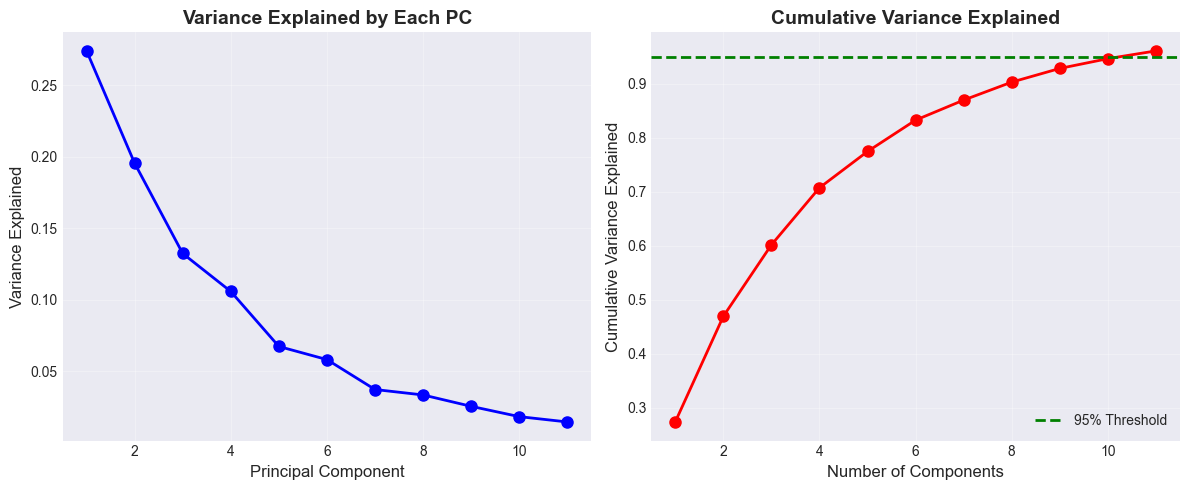

In [17]:
# Check for and handle missing values in selected features
nan_count = df_selected.isna().sum().sum()
if nan_count > 0:
    print(f"⚠️ Found {nan_count} NaN values in selected features")
    
    # Check which features have NaNs
    features_with_nan = df_selected.columns[df_selected.isna().any()].tolist()
    print(f"   Features with NaN: {len(features_with_nan)}")
    print(f"   {features_with_nan}\n")
    
    # Fill NaN values with median (robust to outliers)
    print("🔧 Filling NaN values with feature medians...")
    df_selected = df_selected.fillna(df_selected.median())
    
    # Verify no NaNs remain
    remaining_nans = df_selected.isna().sum().sum()
    print(f"✅ NaN handling complete! Remaining NaNs: {remaining_nans}\n")
else:
    print("✅ No NaN values found in selected features\n")

# Apply PCA with auto-component selection (95% variance)
print("🔧 Applying PCA (95% variance threshold)...")
df_pca, pca_model = selector.apply_pca(df_selected, n_components=None, variance_threshold=0.95)

print(f"\n✅ PCA complete!")
print(f"   - Original features: {df_selected.shape[1]}")
print(f"   - Principal components: {df_pca.shape[1]}")
print(f"   - Variance explained: {pca_model.explained_variance_ratio_.sum():.3f}")
print(f"   - Reduction: {(1 - df_pca.shape[1] / df_selected.shape[1]) * 100:.1f}%")

# Plot variance explained
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), 
         pca_model.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained', fontsize=12)
plt.title('Variance Explained by Each PC', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumsum = np.cumsum(pca_model.explained_variance_ratio_)
plt.plot(range(1, len(cumsum) + 1), cumsum, 'ro-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='green', linestyle='--', linewidth=2, label='95% Threshold')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'pca_variance_explained.png'), dpi=300, bbox_inches='tight')
plt.show()

### 7.2 Feature Importance from PCA

INFO:src.preprocessing.feature_selection:Computed feature importance for 11 PCs


📊 Top 10 Most Important Features per Principal Component:

PC1:
   - std: 0.429
   - mean: 0.382
   - variance: 0.360
   - rolling_std_7: 0.349
   - autocorr_lag_7: 0.321

PC2:
   - entropy: 0.483
   - num_peaks: 0.481
   - zero_count: 0.475
   - weekend_weekday_ratio: 0.321
   - min: 0.192

PC3:
   - autocorr_lag_30: 0.375
   - autocorr_lag_7: 0.337
   - seasonal_strength: 0.332
   - autocorr_lag_1: 0.325
   - rolling_std_7: 0.290

📊 Top 15 Most Important Features (averaged across all PCs):

                  feature  importance
0                      cv    0.245638
1                kurtosis    0.243370
2   weekend_weekday_ratio    0.231780
3       seasonal_strength    0.231039
4                     min    0.212098
5                skewness    0.205615
6         autocorr_lag_30    0.200187
7          autocorr_lag_1    0.199522
8                variance    0.180693
9               num_peaks    0.173736
10    winter_summer_ratio    0.163636
11                entropy    0.148692
12      

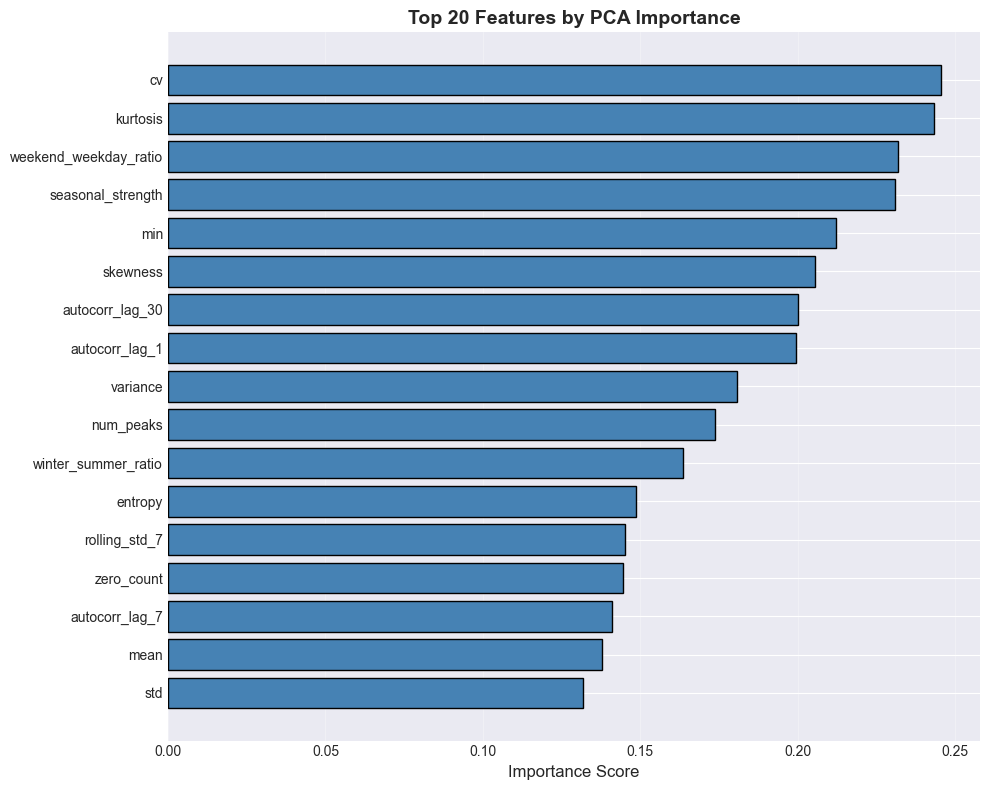

In [19]:
# Get feature importance from PCA loadings
loading_df, importance_summary = selector.get_feature_importance_pca(
    feature_names=df_selected.columns.tolist(), 
    top_n=10
)

print("📊 Top 10 Most Important Features per Principal Component:\n")
for pc, features in list(importance_summary.items())[:3]:  # Show first 3 PCs
    print(f"{pc}:")
    for feat, loading in features.head(5).items():
        print(f"   - {feat}: {loading:.3f}")
    print()

# Calculate overall importance (average absolute loading across all PCs)
overall_importance = loading_df.abs().mean(axis=1).sort_values(ascending=False)
importance_df = pd.DataFrame({
    'feature': overall_importance.index,
    'importance': overall_importance.values
}).reset_index(drop=True)

print("📊 Top 15 Most Important Features (averaged across all PCs):\n")
print(importance_df.head(15))

# Plot top features
plt.figure(figsize=(10, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=10)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Features by PCA Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'pca_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

### 7.3 Save PCA Features

In [20]:
# Save PCA features
pca_features_path = os.path.join(RESULTS_DIR, 'pca_features.csv')
df_pca.to_csv(pca_features_path)
print(f"💾 Saved PCA features to: {pca_features_path}")
print(f"   - Size: {os.path.getsize(pca_features_path) / 1024**2:.2f} MB")

💾 Saved PCA features to: c:\Users\Lundrim\Desktop\RDK Projectt\results\pca_features.csv
   - Size: 3.78 MB


### 7.4 t-SNE Visualization

🔧 Applying t-SNE for 2D visualization...
⏱️ Using sample of 5,000 households for speed...



INFO:src.preprocessing.feature_selection:t-SNE: 17 → 2 components


✅ t-SNE complete!
   - Sample size: 5,000
   - Output shape: (5000, 2)


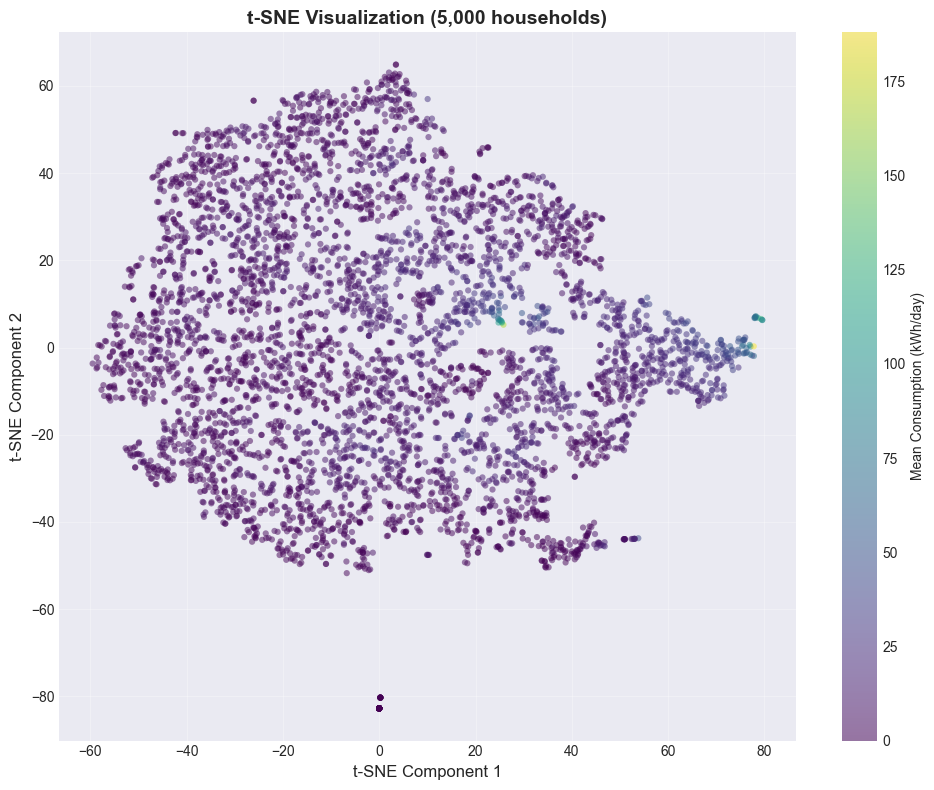


🔧 Computing t-SNE for full dataset...
⏱️ This may take several minutes...



INFO:src.preprocessing.feature_selection:t-SNE: 17 → 2 components


💾 Saved t-SNE features to: c:\Users\Lundrim\Desktop\RDK Projectt\results\tsne_features.csv


In [22]:
# Apply t-SNE (on sample for speed)
print("🔧 Applying t-SNE for 2D visualization...")
print("⏱️ Using sample of 5,000 households for speed...\n")

# Sample for t-SNE (computationally expensive)
sample_size = min(5000, len(df_selected))
df_sample = df_selected.sample(n=sample_size, random_state=42)

df_tsne = selector.apply_tsne(df_sample, n_components=2, perplexity=30.0)

print(f"✅ t-SNE complete!")
print(f"   - Sample size: {sample_size:,}")
print(f"   - Output shape: {df_tsne.shape}")

# Plot t-SNE
plt.figure(figsize=(10, 8))
plt.scatter(df_tsne['tSNE1'], df_tsne['tSNE2'], 
            alpha=0.5, s=20, c=df_sample['mean'] if 'mean' in df_sample.columns else 'steelblue',
            cmap='viridis', edgecolors='none')
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title(f't-SNE Visualization ({sample_size:,} households)', fontsize=14, fontweight='bold')
if 'mean' in df_sample.columns:
    plt.colorbar(label='Mean Consumption (kWh/day)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'tsne_visualization.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save t-SNE features (full dataset - may take longer)
print("\n🔧 Computing t-SNE for full dataset...")
print("⏱️ This may take several minutes...\n")
df_tsne_full = selector.apply_tsne(df_selected, n_components=2, perplexity=30.0)
tsne_features_path = os.path.join(RESULTS_DIR, 'tsne_features.csv')
df_tsne_full.to_csv(tsne_features_path)
print(f"💾 Saved t-SNE features to: {tsne_features_path}")

### 7.5 UMAP Visualization (Optional)

🔧 Applying UMAP for 2D visualization...
⏱️ Using sample of 5,000 households for speed...



INFO:src.preprocessing.feature_selection:UMAP: 17 → 2 components


✅ UMAP complete!
   - Output shape: (5000, 2)


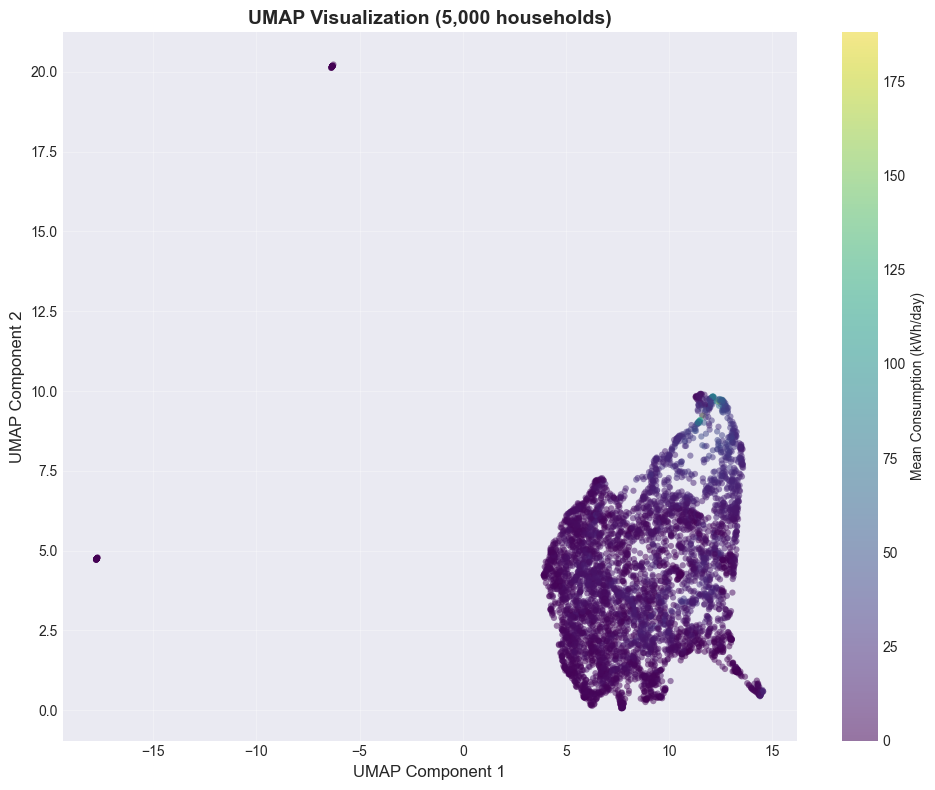

In [23]:
# Apply UMAP if available
try:
    print("🔧 Applying UMAP for 2D visualization...")
    print("⏱️ Using sample of 5,000 households for speed...\n")
    
    df_umap = selector.apply_umap(df_sample, n_components=2, n_neighbors=15, min_dist=0.1)
    
    print(f"✅ UMAP complete!")
    print(f"   - Output shape: {df_umap.shape}")
    
    # Plot UMAP
    plt.figure(figsize=(10, 8))
    plt.scatter(df_umap['UMAP1'], df_umap['UMAP2'], 
                alpha=0.5, s=20, c=df_sample['mean'] if 'mean' in df_sample.columns else 'coral',
                cmap='viridis', edgecolors='none')
    plt.xlabel('UMAP Component 1', fontsize=12)
    plt.ylabel('UMAP Component 2', fontsize=12)
    plt.title(f'UMAP Visualization ({sample_size:,} households)', fontsize=14, fontweight='bold')
    if 'mean' in df_sample.columns:
        plt.colorbar(label='Mean Consumption (kWh/day)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'figures', 'umap_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"⚠️ UMAP not available or failed: {e}")
    print("   Install with: pip install umap-learn")

## 8. Data Scaling & Export

Scale features using StandardScaler and save for clustering.

In [ ]:
# Scale selected features
from src.preprocessing.feature_selection import scale_features

print("🔧 Scaling features (StandardScaler)...")
df_scaled, scaler = scale_features(df_selected, method='standard')

print(f"\n✅ Scaling complete!")
print(f"   - Shape: {df_scaled.shape}")
print(f"   - Mean: {df_scaled.mean().mean():.6f}")
print(f"   - Std: {df_scaled.std().mean():.6f}")

# Verify scaling
print("\n📊 Scaled Feature Statistics (first 5 features):")
print(df_scaled.iloc[:, :5].describe())

🔧 Scaling features (StandardScaler)...


AttributeError: 'FeatureSelector' object has no attribute 'scale_features'

### 8.1 Save Scaled Features

In [ ]:
# Save scaled features
features_scaled_path = os.path.join(RESULTS_DIR, 'features_scaled.csv')
df_scaled.to_csv(features_scaled_path)
print(f"💾 Saved scaled features to: {features_scaled_path}")
print(f"   - Size: {os.path.getsize(features_scaled_path) / 1024**2:.2f} MB")

### 8.2 Save Scaler Object

In [ ]:
# Save scaler for future use
import pickle

scaler_path = os.path.join(RESULTS_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"💾 Saved scaler to: {scaler_path}")
print(f"   - Size: {os.path.getsize(scaler_path) / 1024:.2f} KB")
print("\n✅ Scaler can be loaded later for consistent transformations!")

## 9. Summary & Next Steps

In [ ]:
print("="*80)
print("   Phase 2: Data Preprocessing & Feature Engineering - COMPLETE ✅")
print("="*80)

print("\n📊 Summary:\n")

print(f"1. Data Cleaning:")
print(f"   - Outliers handled with IQR capping")
print(f"   - Zeros preserved ({zero_pct:.2f}% of data)")
print(f"   - All {df_cleaned.shape[0]:,} households preserved")

print(f"\n2. Feature Extraction:")
print(f"   - Total features extracted: {df_features.shape[1]}")
print(f"   - Statistical: {len(statistical_features)}")
print(f"   - Temporal: {len(temporal_features)}")
print(f"   - Seasonality: {len(seasonality_features)}")
print(f"   - Variability: {len(variability_features)}")
print(f"   - Shape: {len(shape_features)}")

print(f"\n3. Feature Selection:")
print(f"   - Original features: {df_features.shape[1]}")
print(f"   - After correlation filter: {df_selected.shape[1]}")
print(f"   - Reduction: {(1 - df_selected.shape[1] / df_features.shape[1]) * 100:.1f}%")

print(f"\n4. Dimensionality Reduction:")
print(f"   - PCA components: {df_pca.shape[1]}")
print(f"   - Variance explained: {pca_model.explained_variance_ratio_.sum():.1f}%")
print(f"   - t-SNE: 2D projection computed")

print(f"\n5. Data Scaling:")
print(f"   - Method: StandardScaler (z-score)")
print(f"   - Features scaled: {df_scaled.shape[1]}")
print(f"   - Scaler saved for reproducibility")

print("\n📁 Generated Files:\n")
files_generated = [
    features_all_path,
    features_selected_path,
    features_scaled_path,
    pca_features_path,
    tsne_features_path,
    scaler_path
]

for filepath in files_generated:
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / 1024**2
        print(f"   ✅ {os.path.basename(filepath)} ({size_mb:.2f} MB)")

print("\n🎯 Next Steps (Phase 3: Clustering):\n")
print("   1. Load features_scaled.csv")
print("   2. Apply K-Means, DBSCAN, Hierarchical clustering")
print("   3. Determine optimal number of clusters")
print("   4. Evaluate clustering quality (silhouette, Davies-Bouldin)")
print("   5. Visualize clusters using t-SNE/UMAP")
print("   6. Interpret cluster characteristics")

print("\n⏰ Notebook completed:", datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print("="*80)

---

## Phase 2 Complete! ✅

**Key Achievements:**
- ✅ Comprehensive data cleaning pipeline
- ✅ 69+ features extracted across 5 categories
- ✅ Feature selection and correlation filtering
- ✅ PCA dimensionality reduction (95% variance)
- ✅ t-SNE/UMAP visualizations
- ✅ Feature scaling and persistence

**Ready for Phase 3: Clustering!** 🚀

---